
# EcoShield AI — IEEE-CIS Fraud Detection EDA

Bu notebook, IEEE-CIS veri setini model eğitiminden önce analiz eder.

Yapılanlar:
- `train_transaction.csv` ve `train_identity.csv` okunur.
- Dosyalar `TransactionID` üzerinden birleştirilir.
- Veri boyutu, target dağılımı, duplicate, kolon tipleri ve identity kapsaması incelenir.
- Eksik değerler, `TransactionAmt`, `TransactionDT`, temel kategorik alanlar ve sayısal korelasyonlar analiz edilir.
- Sonuç tabloları ve görseller `assets/sprint-2/ieee-eda/` klasörüne kaydedilir.

> Bu notebook model eğitmez, threshold seçmez ve submission üretmez.



## Beklenen klasör yapısı

```text
YZTA-Bootcamp-2026/
├── data/raw/
│   ├── train_transaction.csv
│   └── train_identity.csv
├── notebooks/
│   ├── 01_eda.ipynb
│   └── 02_ieee_cis_eda.ipynb
└── assets/sprint-2/ieee-eda/
```


In [1]:

# 1) AYARLAR
PLOT_SAMPLE_SIZE = 200_000
TOP_MISSING_COLUMNS = 30
TOP_CORRELATION_COLUMNS = 30
TOP_CATEGORIES = 15
RANDOM_STATE = 42

print('Ayarlar hazır.')


Ayarlar hazır.


In [2]:

# 2) PAKET KONTROLÜ
import importlib.util, subprocess, sys
required = {
    'pandas':'pandas', 'numpy':'numpy', 'matplotlib':'matplotlib',
    'tqdm':'tqdm', 'psutil':'psutil'
}
missing=[pip for imp,pip in required.items() if importlib.util.find_spec(imp) is None]
if missing:
    print('Eksik paketler kuruluyor:', missing)
    subprocess.check_call([sys.executable,'-m','pip','install',*missing])
else:
    print('Gerekli paketler kurulu.')


Gerekli paketler kurulu.


In [3]:

# 3) IMPORTLAR
import gc, json, os, time, warnings
from contextlib import contextmanager
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 150)
pd.set_option('display.max_rows', 120)


c:\Users\pc\anaconda3\envs\torchcuda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:

# 4) PROJE KÖKÜ VE YARDIMCI FONKSİYONLAR

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate/'data').exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DIR = PROJECT_ROOT/'data'/'raw'
OUTPUT_DIR = PROJECT_ROOT/'assets'/'sprint-2'/'ieee-eda'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def ram_gb():
    return psutil.Process(os.getpid()).memory_info().rss/(1024**3)

@contextmanager
def step(name):
    start=time.perf_counter()
    print()
    print('='*70)
    print('BAŞLADI:', name)
    print('='*70)
    yield
    print(f'TAMAMLANDI: {name} — {time.perf_counter()-start:.1f} sn | RAM: {ram_gb():.2f} GB')

def locate(filename):
    direct=[RAW_DIR/filename, PROJECT_ROOT/'data'/filename, PROJECT_ROOT/filename]
    for p in direct:
        if p.exists(): return p
    found=[]
    for root in [RAW_DIR, PROJECT_ROOT/'data', PROJECT_ROOT]:
        if root.exists(): found.extend(root.rglob(filename))
    if not found:
        raise FileNotFoundError(f'{filename} bulunamadı. data/raw altına koyun.')
    return found[0]

def downcast(df):
    for col in tqdm(df.select_dtypes('float64').columns, desc='Float küçültme', leave=False):
        df[col]=pd.to_numeric(df[col], downcast='float')
    for col in tqdm(df.select_dtypes('int64').columns, desc='Integer küçültme', leave=False):
        df[col]=pd.to_numeric(df[col], downcast='integer')
    return df

def read_csv(path):
    with step(f'{path.name} okunuyor'):
        df=pd.read_csv(path, low_memory=False)
        df=downcast(df)
    print(path.name, df.shape)
    return df

def savefig(name):
    path=OUTPUT_DIR/name
    plt.tight_layout()
    plt.savefig(path, dpi=170, bbox_inches='tight')
    print('Kaydedildi:', path)
    return path

print('Proje kökü:', PROJECT_ROOT)
print('Çıktı klasörü:', OUTPUT_DIR)


Proje kökü: C:\Users\pc\Desktop\YZTA-Bootcamp-2026
Çıktı klasörü: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda


In [5]:

# 5) DOSYALARI BUL VE OKU
TRANSACTION_PATH = locate('train_transaction.csv')
IDENTITY_PATH = locate('train_identity.csv')
print('Transaction:', TRANSACTION_PATH)
print('Identity:', IDENTITY_PATH)

train_transaction = read_csv(TRANSACTION_PATH)
train_identity = read_csv(IDENTITY_PATH)


Transaction: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\data\raw\train_transaction.csv
Identity: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\data\raw\train_identity.csv

BAŞLADI: train_transaction.csv okunuyor


TAMAMLANDI: train_transaction.csv okunuyor — 15.0 sn | RAM: 1.07 GB
train_transaction.csv (590540, 394)

BAŞLADI: train_identity.csv okunuyor


TAMAMLANDI: train_identity.csv okunuyor — 0.4 sn | RAM: 1.11 GB
train_identity.csv (144233, 41)


In [6]:

# 6) TRANSACTION + IDENTITY BİRLEŞTİR
identity_ids=set(train_identity['TransactionID'].dropna().tolist())
with step('Transaction ve identity birleştirme'):
    train_df=train_transaction.merge(
        train_identity,
        on='TransactionID',
        how='left',
        validate='one_to_one',
        suffixes=('', '_identity')
    )
    train_df['_has_identity']=train_df['TransactionID'].isin(identity_ids).astype('int8')
print('Birleşik shape:', train_df.shape)
del train_identity
gc.collect()



BAŞLADI: Transaction ve identity birleştirme
TAMAMLANDI: Transaction ve identity birleştirme — 0.2 sn | RAM: 1.26 GB
Birleşik shape: (590540, 435)


20

# 1. Genel Veri Özeti

In [7]:

# 7) GENEL ÖZET
if 'isFraud' not in train_df.columns:
    raise KeyError('isFraud kolonu bulunamadı.')
fraud_count=int(train_df['isFraud'].sum())
normal_count=int((train_df['isFraud']==0).sum())
fraud_ratio=float(train_df['isFraud'].mean())

overview=pd.DataFrame([
    ['Train transaction satır', len(train_transaction)],
    ['Train transaction kolon', train_transaction.shape[1]],
    ['Birleşik train satır', len(train_df)],
    ['Birleşik train kolon', train_df.shape[1]],
    ['Normal işlem', normal_count],
    ['Fraud işlem', fraud_count],
    ['Fraud oranı', fraud_ratio],
    ['Normal/Fraud oranı', normal_count/max(fraud_count,1)],
    ['Duplicate satır', int(train_df.duplicated().sum())],
    ['Identity kapsama oranı', float(train_df['_has_identity'].mean())],
], columns=['Metrik','Değer'])
display(overview)
overview.to_csv(OUTPUT_DIR/'ieee_dataset_overview.csv', index=False)

dtype_summary=train_df.dtypes.astype(str).value_counts().rename_axis('dtype').reset_index(name='column_count')
display(dtype_summary)
dtype_summary.to_csv(OUTPUT_DIR/'ieee_dtype_summary.csv', index=False)


,Metrik,Değer
0,Train transaction satır,590540.000000
1,Train transaction kolon,394.000000
2,Birleşik train satır,590540.000000
3,Birleşik train kolon,435.000000
4,Normal işlem,569877.000000
5,Fraud işlem,20663.000000
6,Fraud oranı,0.034990
7,Normal/Fraud oranı,27.579587
8,Duplicate satır,0.000000
9,Identity kapsama oranı,0.244239


,dtype,column_count
0,float32,399
1,str,31
2,int32,2
3,int8,2
4,int16,1


# 2. Class Imbalance ve Identity Kapsaması

Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\01_class_distribution.png


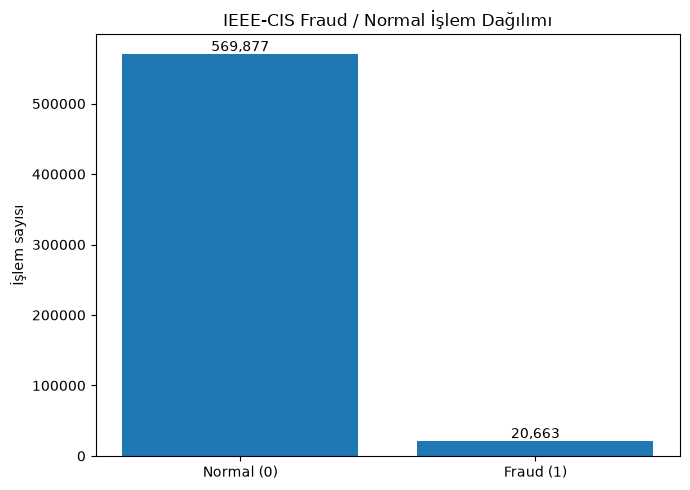

Fraud oranı: 3.4990%
Normal/Fraud oranı: 27.58


In [8]:

# 8) CLASS DAĞILIMI
counts=train_df['isFraud'].value_counts().sort_index()
plt.figure(figsize=(7,5))
vals=[counts.get(0,0), counts.get(1,0)]
plt.bar(['Normal (0)','Fraud (1)'], vals)
plt.title('IEEE-CIS Fraud / Normal İşlem Dağılımı')
plt.ylabel('İşlem sayısı')
for i,v in enumerate(vals): plt.text(i,v,f'{v:,}',ha='center',va='bottom')
savefig('01_class_distribution.png')
plt.show(); plt.close()
print('Fraud oranı:', f'{fraud_ratio:.4%}')
print('Normal/Fraud oranı:', f'{normal_count/max(fraud_count,1):.2f}')


,_has_identity,transaction_count,fraud_count,fraud_rate
0,Identity yok,446307,9345,0.020939
1,Identity var,144233,11318,0.078470


Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\02_identity_presence_fraud_rate.png


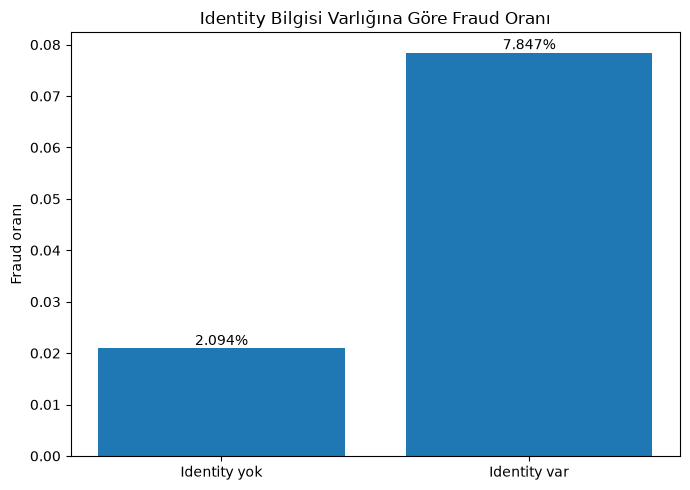

In [9]:

# 9) IDENTITY VARLIĞINA GÖRE FRAUD
identity_summary=(train_df.groupby('_has_identity')['isFraud']
                  .agg(transaction_count='count', fraud_count='sum', fraud_rate='mean')
                  .reset_index())
identity_summary['_has_identity']=identity_summary['_has_identity'].map({0:'Identity yok',1:'Identity var'})
display(identity_summary)
identity_summary.to_csv(OUTPUT_DIR/'ieee_identity_fraud_summary.csv', index=False)
plt.figure(figsize=(7,5))
plt.bar(identity_summary['_has_identity'], identity_summary['fraud_rate'])
plt.title('Identity Bilgisi Varlığına Göre Fraud Oranı')
plt.ylabel('Fraud oranı')
for i,v in enumerate(identity_summary['fraud_rate']): plt.text(i,v,f'{v:.3%}',ha='center',va='bottom')
savefig('02_identity_presence_fraud_rate.png')
plt.show(); plt.close()


# 3. Eksik Değer Analizi


BAŞLADI: Eksik değer ve unique sayıları


Unique hesaplanıyor: 100%|██████████| 435/435 [00:01<00:00, 357.08it/s]

TAMAMLANDI: Eksik değer ve unique sayıları — 1.6 sn | RAM: 1.26 GB


,column,dtype,missing_count,missing_ratio,unique_count
0,id_24,float32,585793,0.991962,12
1,id_25,float32,585408,0.991310,341
2,id_07,float32,585385,0.991271,84
3,id_08,float32,585385,0.991271,94
4,id_21,float32,585381,0.991264,490
5,id_26,float32,585377,0.991257,95
6,id_27,str,585371,0.991247,2
7,id_23,str,585371,0.991247,3
8,id_22,float32,585371,0.991247,25
9,dist2,float32,552913,0.936284,1751


Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\03_top_missing_columns.png


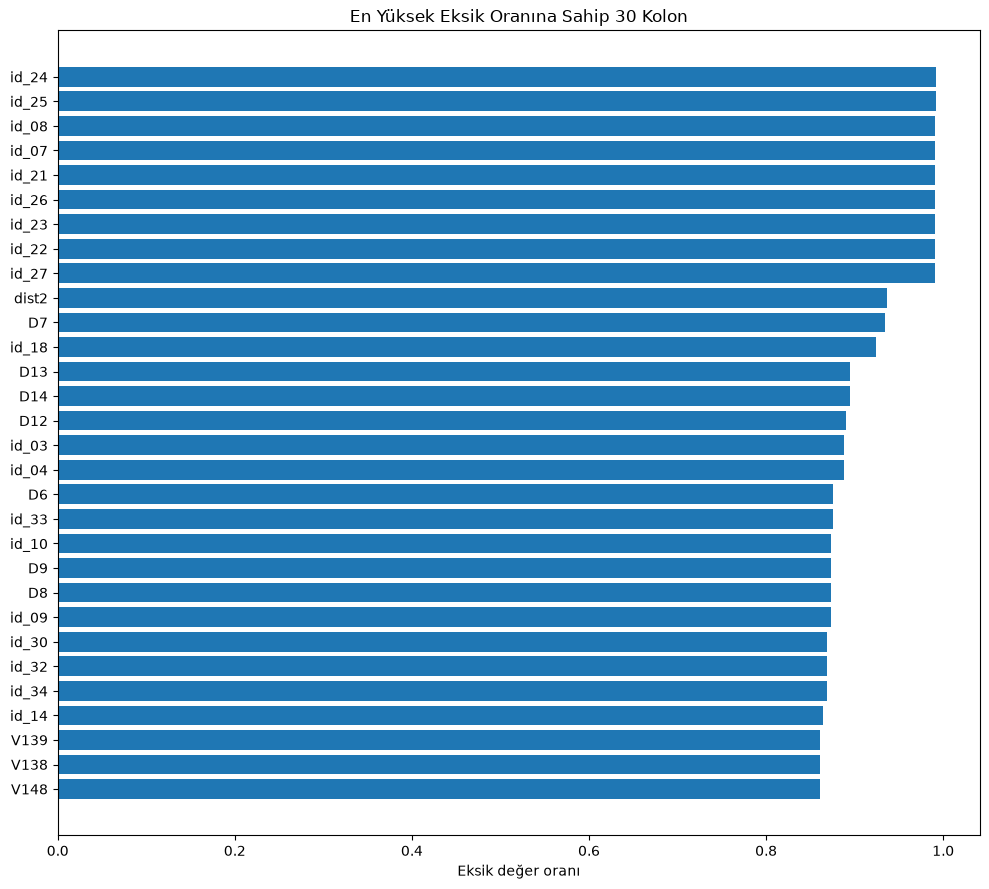

In [10]:

# 10) EKSİK DEĞER RAPORU
with step('Eksik değer ve unique sayıları'):
    missing_report=pd.DataFrame({
        'column':train_df.columns,
        'dtype':train_df.dtypes.astype(str).values,
        'missing_count':train_df.isna().sum().values,
        'missing_ratio':train_df.isna().mean().values,
        'unique_count':[train_df[c].nunique(dropna=True) for c in tqdm(train_df.columns, desc='Unique hesaplanıyor')]
    }).sort_values('missing_ratio', ascending=False).reset_index(drop=True)

display(missing_report.head(TOP_MISSING_COLUMNS))
missing_report.to_csv(OUTPUT_DIR/'ieee_missing_value_report.csv', index=False)

top=missing_report.head(TOP_MISSING_COLUMNS).sort_values('missing_ratio')
plt.figure(figsize=(10,9))
plt.barh(top['column'], top['missing_ratio'])
plt.title(f'En Yüksek Eksik Oranına Sahip {TOP_MISSING_COLUMNS} Kolon')
plt.xlabel('Eksik değer oranı')
savefig('03_top_missing_columns.png')
plt.show(); plt.close()


# 4. Transaction Amount Analizi

,isFraud,count,mean,median,std,min,max
0,0,569877,134.511658,68.5,239.395081,0.251,31937.390625
1,1,20663,149.244766,75.0,232.212158,0.292,5191.000000


Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\04_transaction_amount_log_distribution.png


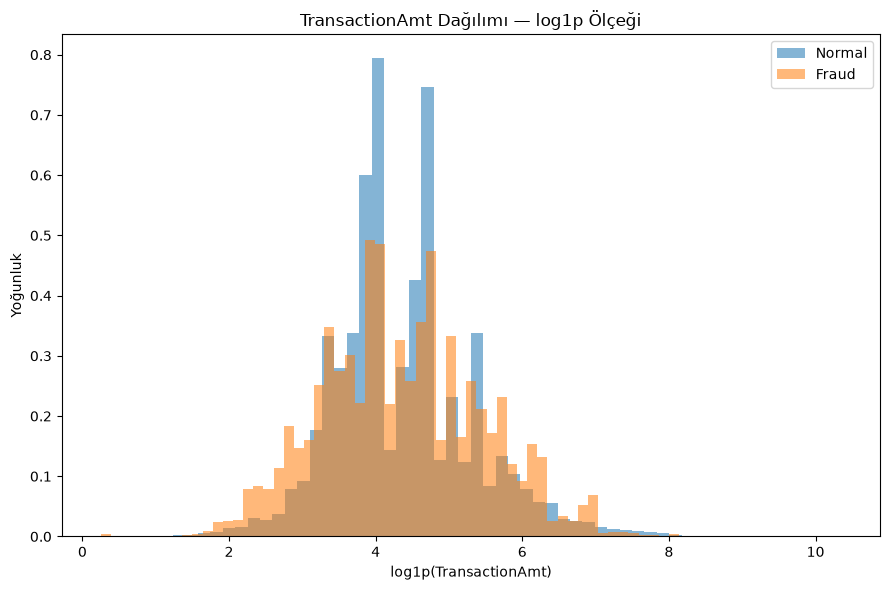

In [11]:

# 11) TRANSACTION AMOUNT
amount_summary=(train_df.groupby('isFraud')['TransactionAmt']
                .agg(count='count', mean='mean', median='median', std='std', min='min', max='max')
                .reset_index())
display(amount_summary)
amount_summary.to_csv(OUTPUT_DIR/'ieee_transaction_amount_summary.csv', index=False)

plot_df=train_df[['TransactionAmt','isFraud']].dropna()
if len(plot_df)>PLOT_SAMPLE_SIZE:
    plot_df=plot_df.sample(PLOT_SAMPLE_SIZE, random_state=RANDOM_STATE)
plot_df['log_amount']=np.log1p(plot_df['TransactionAmt'].clip(lower=0))
plt.figure(figsize=(9,6))
for cls,label in [(0,'Normal'),(1,'Fraud')]:
    plt.hist(plot_df.loc[plot_df['isFraud']==cls,'log_amount'], bins=60, alpha=.55, density=True, label=label)
plt.title('TransactionAmt Dağılımı — log1p Ölçeği')
plt.xlabel('log1p(TransactionAmt)')
plt.ylabel('Yoğunluk')
plt.legend()
savefig('04_transaction_amount_log_distribution.png')
plt.show(); plt.close()


# 5. TransactionDT Zaman Analizi

,_transaction_day,transaction_count,fraud_count,fraud_rate
0,1,5122,112,0.021866
1,2,3730,123,0.032976
2,3,3241,92,0.028386
3,4,4036,115,0.028494
4,5,3964,127,0.032038


Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\05_daily_transaction_count.png


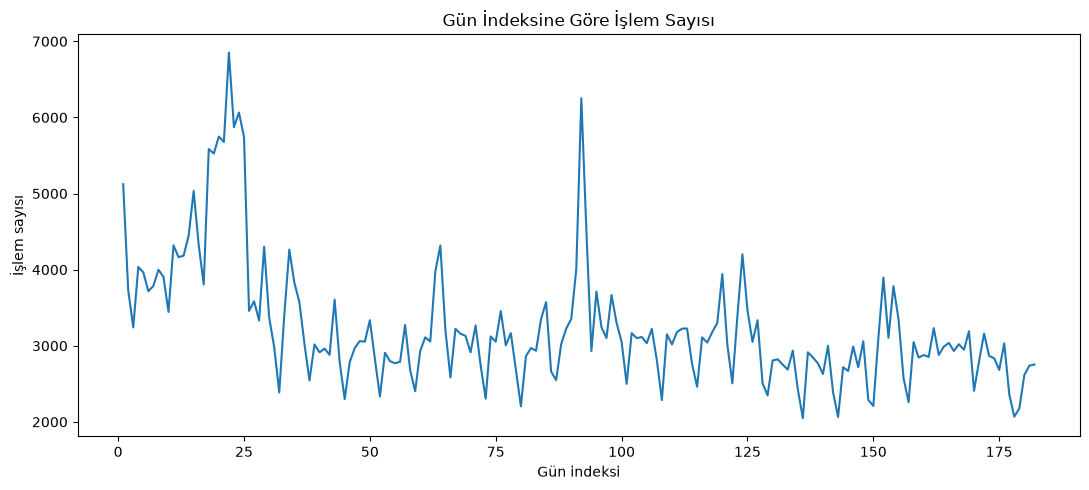

Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\06_daily_fraud_rate.png


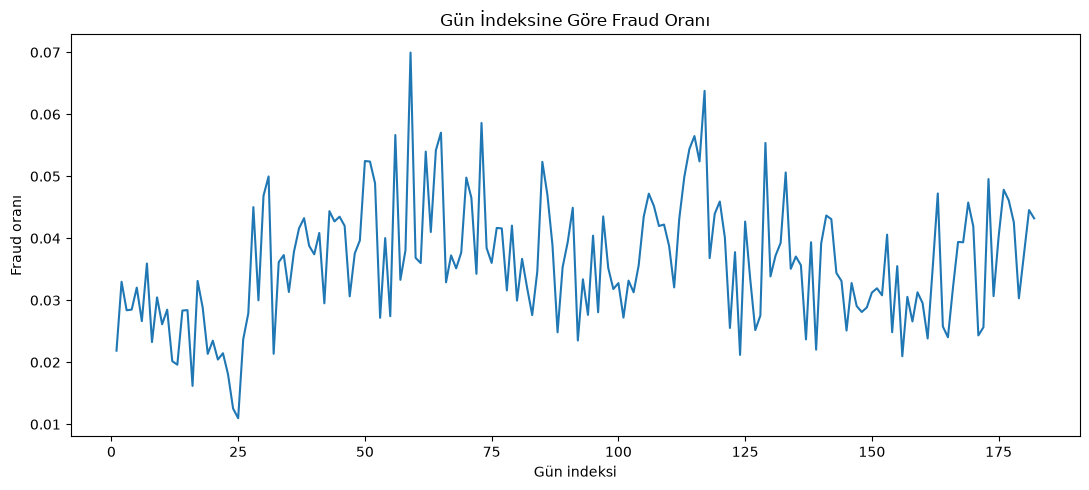

In [12]:

# 12) GÜN BAZLI İŞLEM VE FRAUD ORANI
train_df['_transaction_day']=(train_df['TransactionDT']//86400).astype('int32')
daily=(train_df.groupby('_transaction_day')['isFraud']
       .agg(transaction_count='count', fraud_count='sum', fraud_rate='mean')
       .reset_index())
daily.to_csv(OUTPUT_DIR/'ieee_daily_transaction_summary.csv', index=False)
display(daily.head())

plt.figure(figsize=(11,5))
plt.plot(daily['_transaction_day'], daily['transaction_count'])
plt.title('Gün İndeksine Göre İşlem Sayısı')
plt.xlabel('Gün indeksi'); plt.ylabel('İşlem sayısı')
savefig('05_daily_transaction_count.png')
plt.show(); plt.close()

plt.figure(figsize=(11,5))
plt.plot(daily['_transaction_day'], daily['fraud_rate'])
plt.title('Gün İndeksine Göre Fraud Oranı')
plt.xlabel('Gün indeksi'); plt.ylabel('Fraud oranı')
savefig('06_daily_fraud_rate.png')
plt.show(); plt.close()


# 6. Temel Kategorik Değişkenler

Kategorik analiz:   0%|          | 0/15 [00:00<?, ?it/s]

Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\categorical_ProductCD_fraud_rate.png


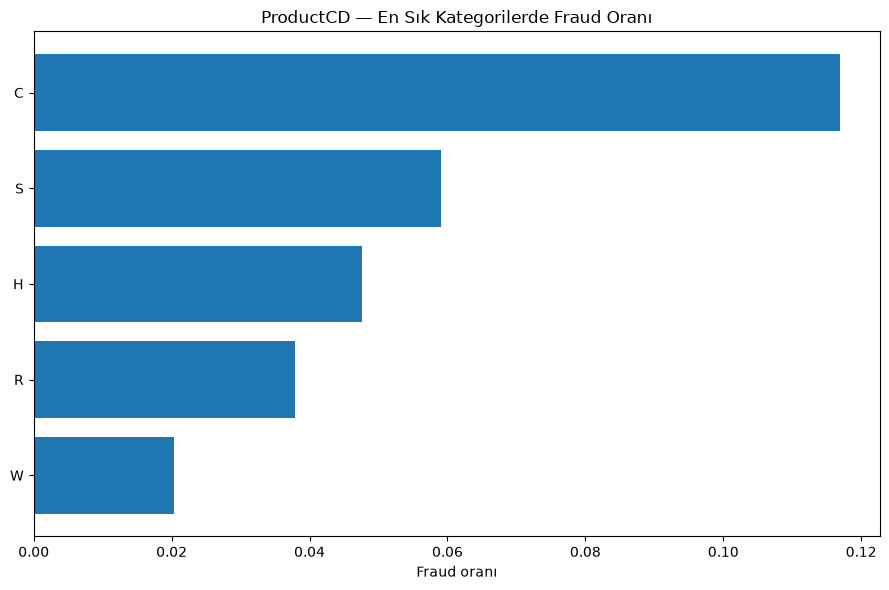

Kategorik analiz:   7%|▋         | 1/15 [00:00<00:01,  7.81it/s]

Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\categorical_card4_fraud_rate.png


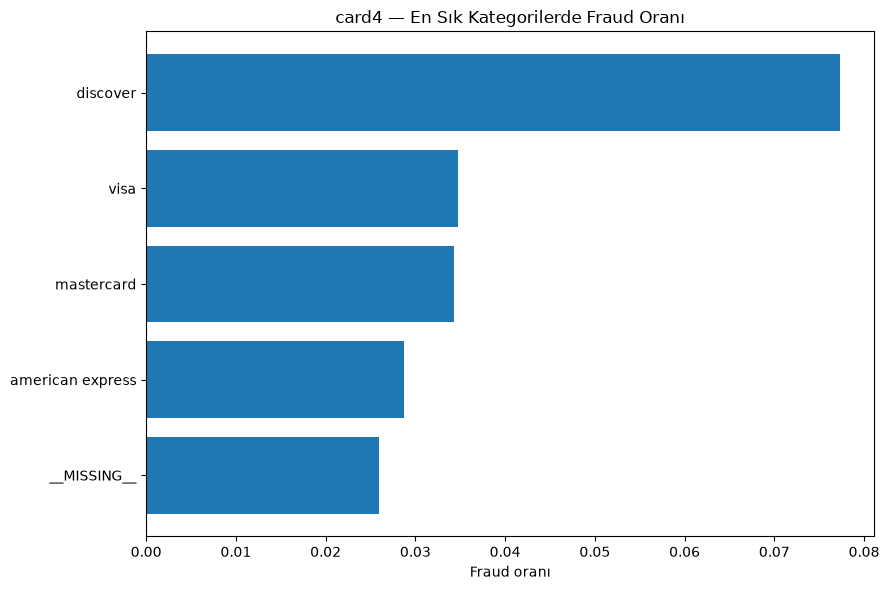

Kategorik analiz:  13%|█▎        | 2/15 [00:00<00:01,  7.22it/s]

Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\categorical_card6_fraud_rate.png


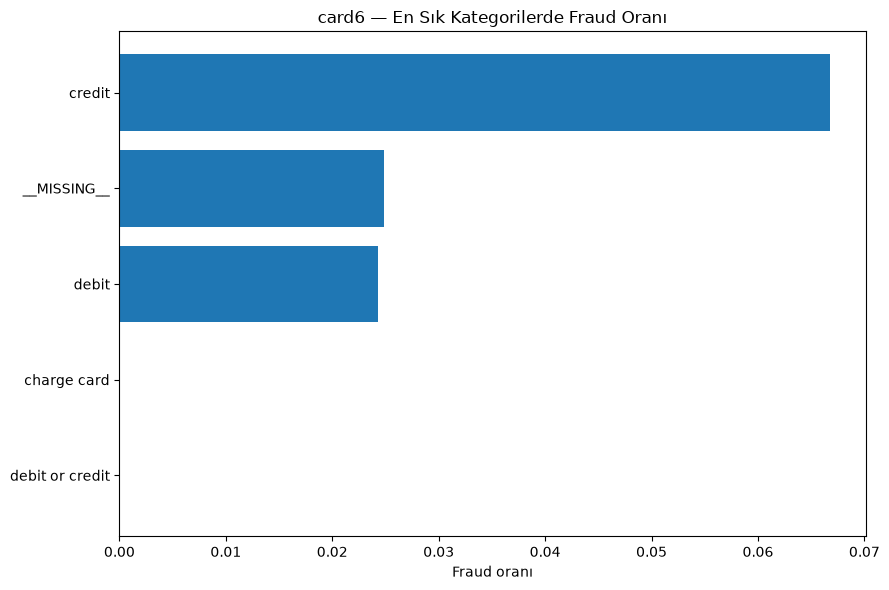

Kategorik analiz:  20%|██        | 3/15 [00:00<00:01,  7.26it/s]

Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\categorical_DeviceType_fraud_rate.png


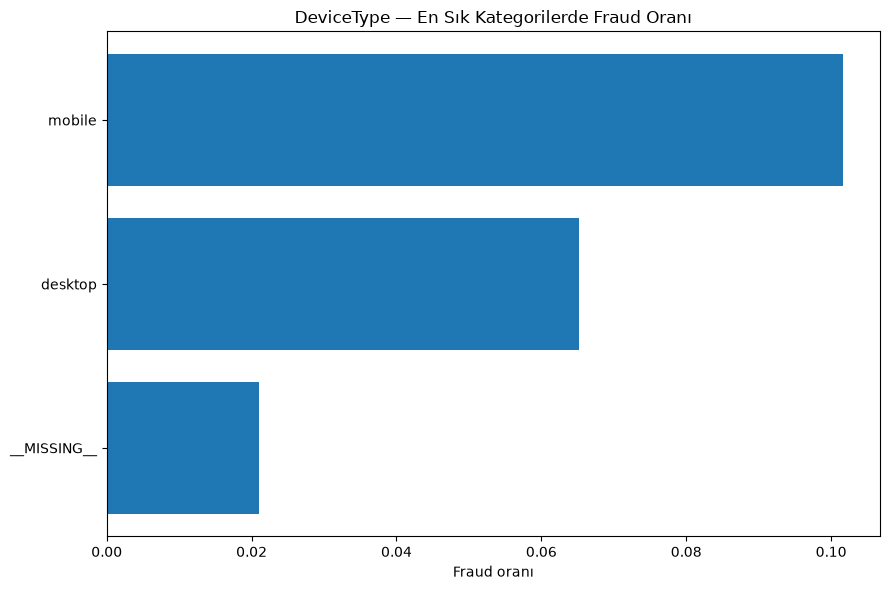

Kategorik analiz:  27%|██▋       | 4/15 [00:00<00:01,  7.53it/s]

Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\categorical_P_emaildomain_fraud_rate.png


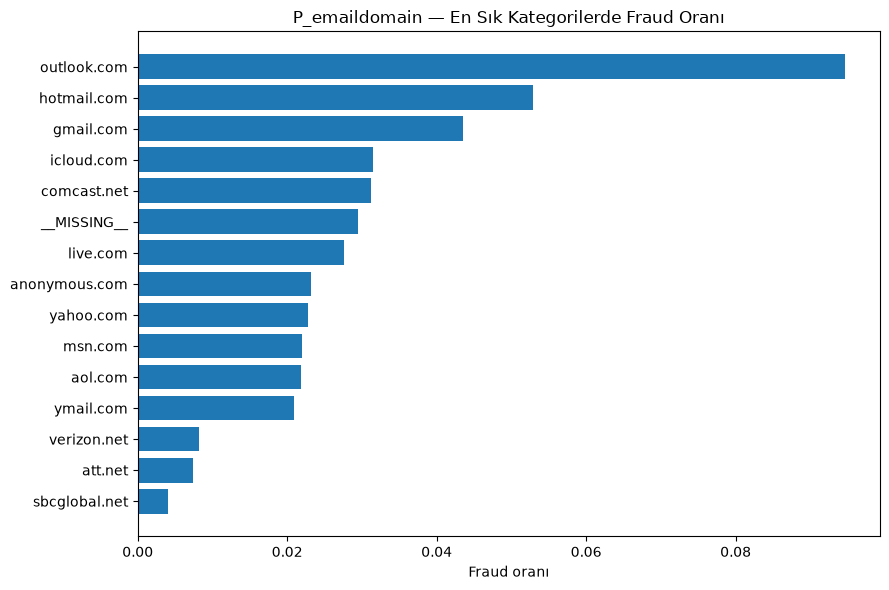

Kategorik analiz:  33%|███▎      | 5/15 [00:00<00:01,  6.35it/s]

Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\categorical_R_emaildomain_fraud_rate.png


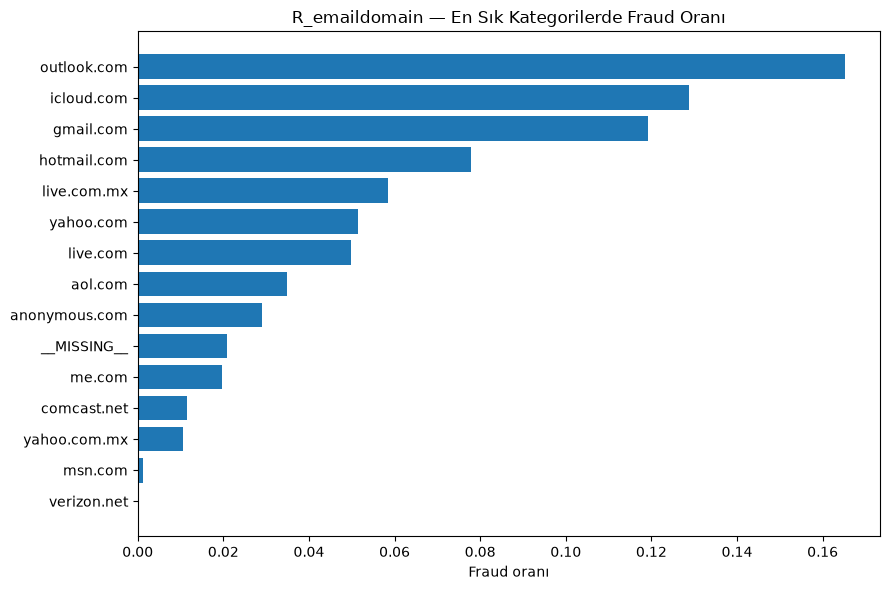

Kategorik analiz:  40%|████      | 6/15 [00:00<00:01,  5.53it/s]

Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\categorical_M1_fraud_rate.png


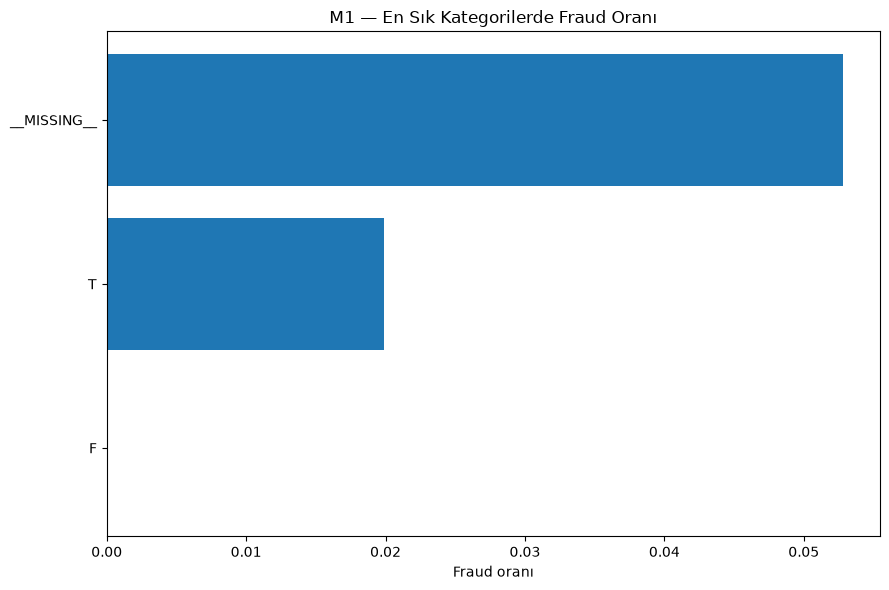

Kategorik analiz:  47%|████▋     | 7/15 [00:01<00:01,  6.36it/s]

Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\categorical_M2_fraud_rate.png


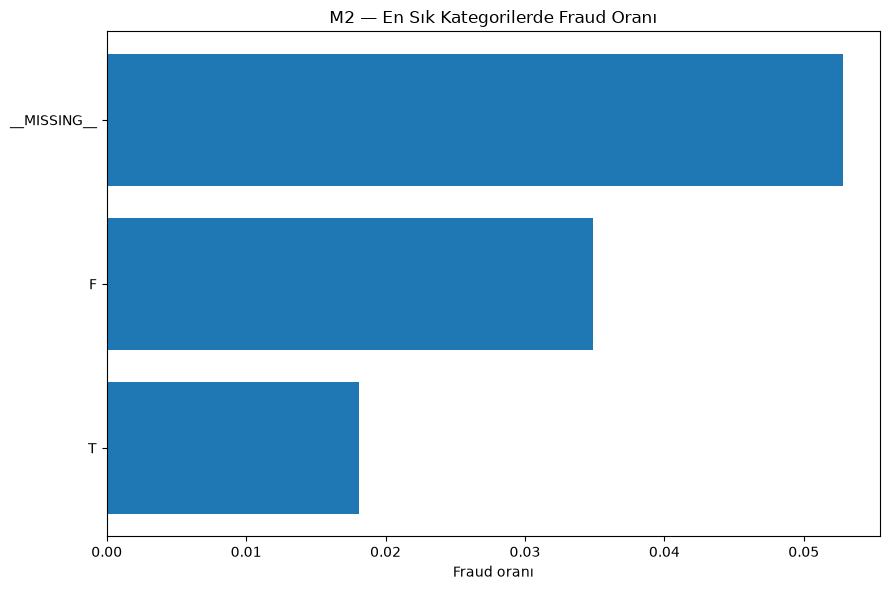

Kategorik analiz:  53%|█████▎    | 8/15 [00:01<00:00,  7.13it/s]

Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\categorical_M3_fraud_rate.png


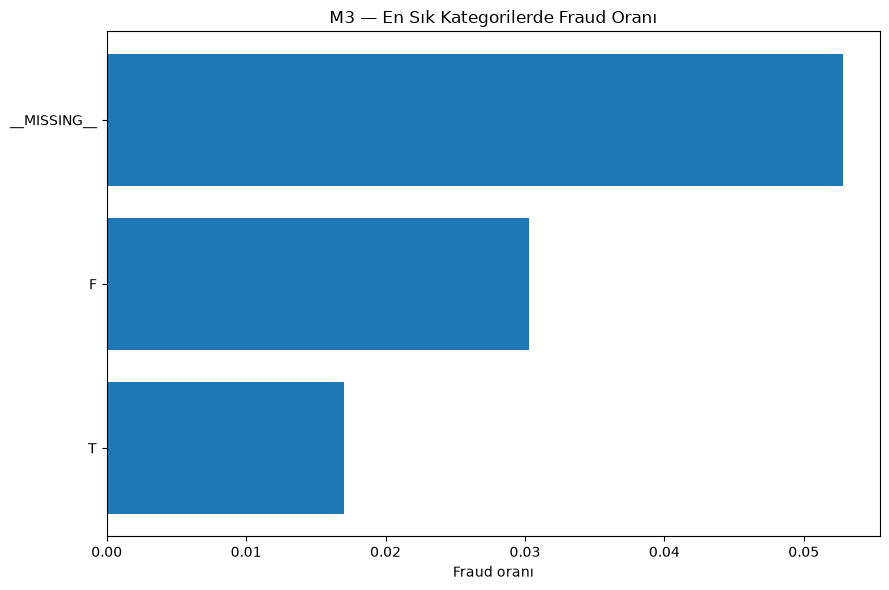

Kategorik analiz:  60%|██████    | 9/15 [00:01<00:00,  7.60it/s]

Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\categorical_M4_fraud_rate.png


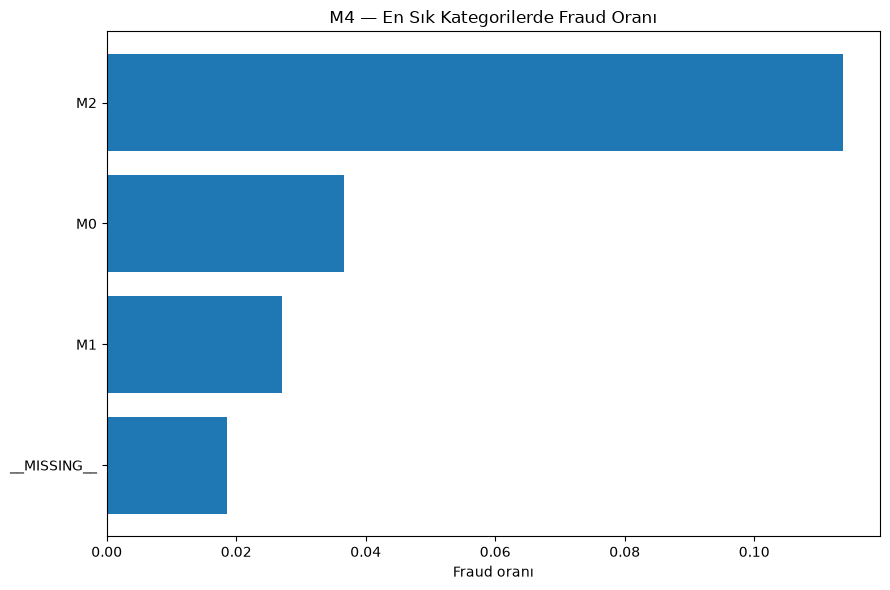

Kategorik analiz:  67%|██████▋   | 10/15 [00:01<00:00,  7.96it/s]

Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\categorical_M5_fraud_rate.png


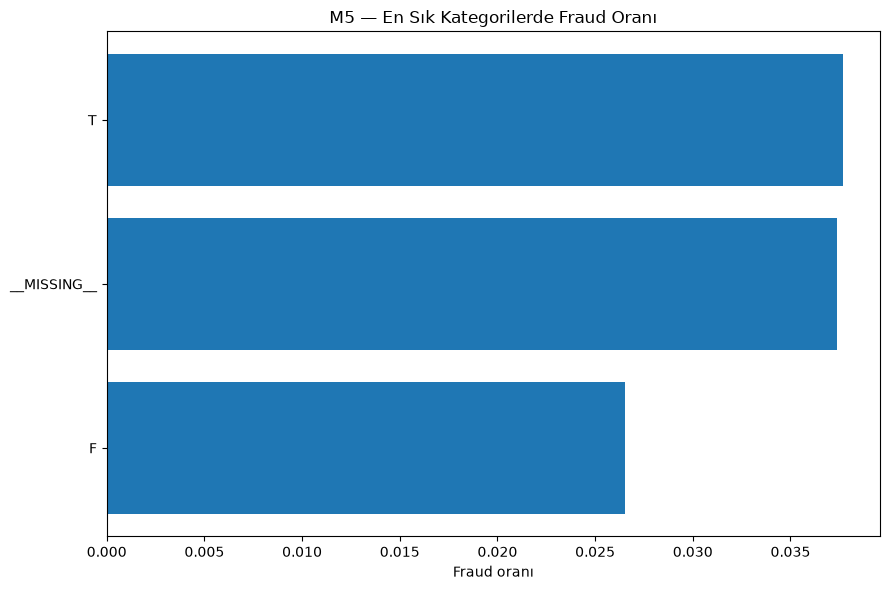

Kategorik analiz:  73%|███████▎  | 11/15 [00:01<00:00,  7.10it/s]

Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\categorical_M6_fraud_rate.png


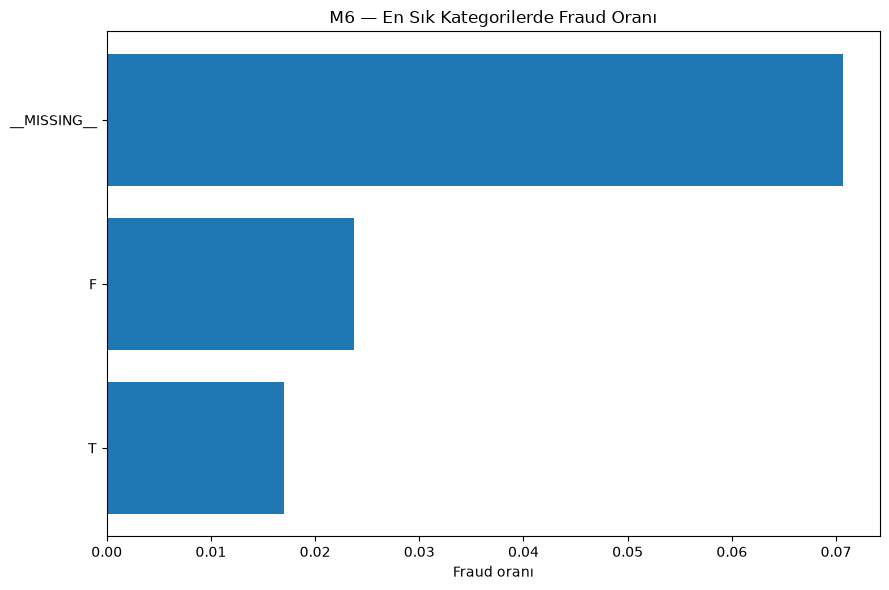

Kategorik analiz:  80%|████████  | 12/15 [00:01<00:00,  7.49it/s]

Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\categorical_M7_fraud_rate.png


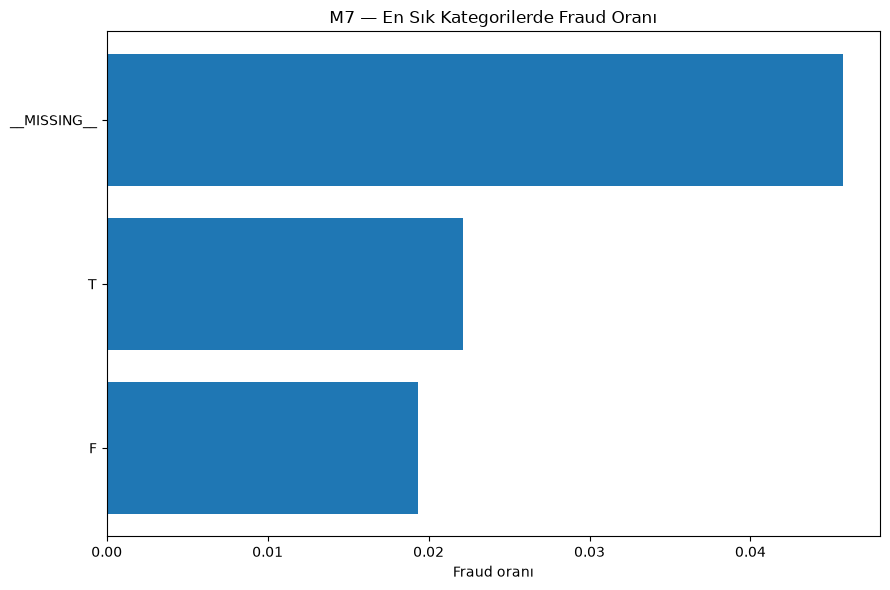

Kategorik analiz:  87%|████████▋ | 13/15 [00:01<00:00,  7.87it/s]

Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\categorical_M8_fraud_rate.png


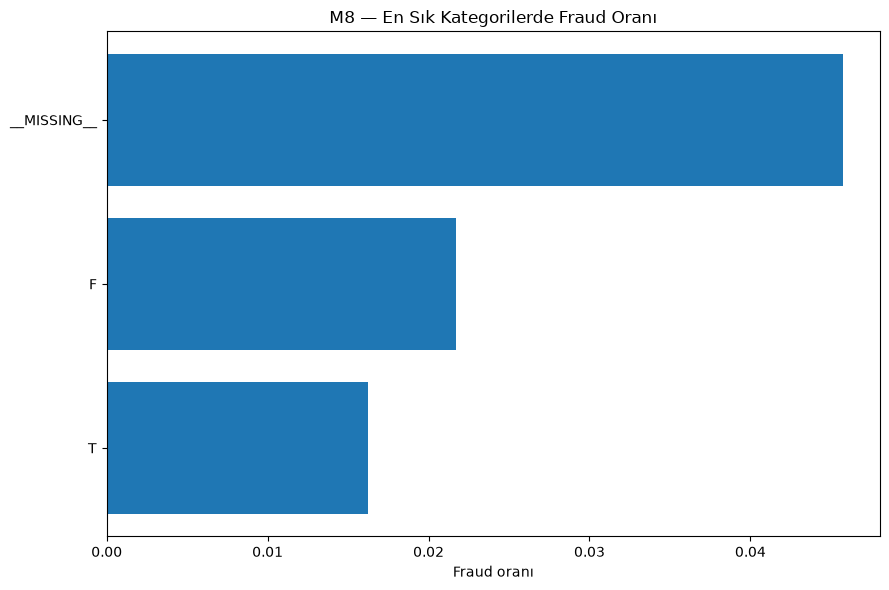

Kategorik analiz:  93%|█████████▎| 14/15 [00:01<00:00,  8.17it/s]

Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\categorical_M9_fraud_rate.png


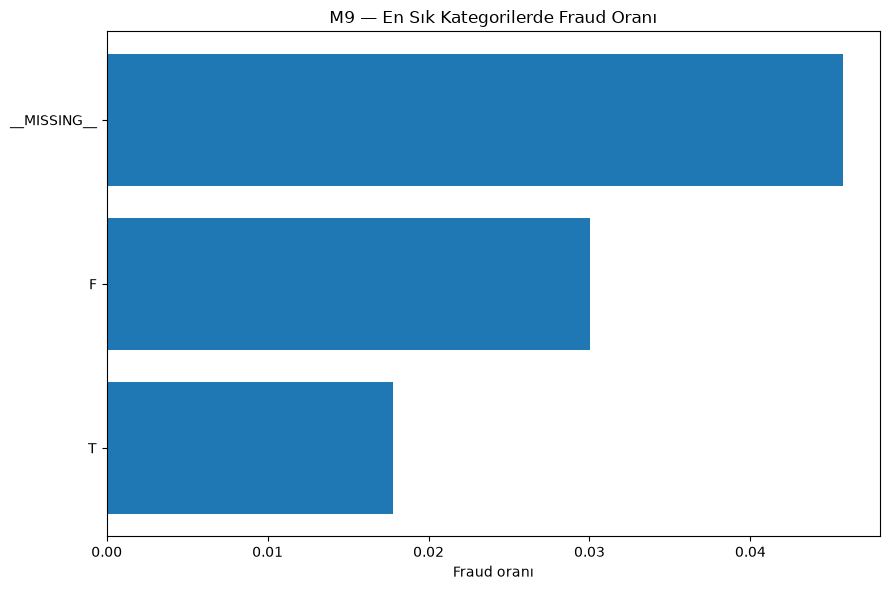

Kategorik analiz: 100%|██████████| 15/15 [00:02<00:00,  7.42it/s]


,feature,ProductCD,transaction_count,fraud_count,fraud_rate,card4,card6,DeviceType,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,M6,M7,M8,M9
0,ProductCD,W,439670,8969,0.020399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ProductCD,C,68519,8008,0.116873,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ProductCD,R,37699,1426,0.037826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ProductCD,H,33024,1574,0.047662,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ProductCD,S,11628,686,0.058996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,card4,NaN,384767,13373,0.034756,visa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,card4,NaN,189217,6496,0.034331,mastercard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,card4,NaN,8328,239,0.028698,american express,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,card4,NaN,6651,514,0.077282,discover,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,card4,NaN,1577,41,0.025999,__MISSING__,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:

# 13) KATEGORİK FRAUD ÖZETLERİ
candidates=['ProductCD','card4','card6','DeviceType','P_emaildomain','R_emaildomain']+[f'M{i}' for i in range(1,10)]
candidates=[c for c in candidates if c in train_df.columns]
reports=[]
for col in tqdm(candidates, desc='Kategorik analiz'):
    work=train_df[[col,'isFraud']].copy()
    work[col]=work[col].where(work[col].notna(),'__MISSING__').astype(str)
    s=(work.groupby(col)['isFraud']
       .agg(transaction_count='count', fraud_count='sum', fraud_rate='mean')
       .reset_index()
       .sort_values('transaction_count',ascending=False)
       .head(TOP_CATEGORIES))
    s.insert(0,'feature',col)
    reports.append(s)
    s.to_csv(OUTPUT_DIR/f'categorical_{col}_summary.csv', index=False)
    p=s.sort_values('fraud_rate')
    plt.figure(figsize=(9,6))
    plt.barh(p[col], p['fraud_rate'])
    plt.title(f'{col} — En Sık Kategorilerde Fraud Oranı')
    plt.xlabel('Fraud oranı')
    savefig(f'categorical_{col}_fraud_rate.png')
    plt.show(); plt.close()
if reports:
    categorical_report=pd.concat(reports, ignore_index=True)
    categorical_report.to_csv(OUTPUT_DIR/'ieee_categorical_fraud_report.csv', index=False)
    display(categorical_report.head(30))


# 7. Sayısal Feature — isFraud Korelasyonu


BAŞLADI: Sayısal target korelasyonları
TAMAMLANDI: Sayısal target korelasyonları — 31.3 sn | RAM: 1.58 GB


,feature,correlation_with_isFraud
0,V257,0.373806
1,V244,0.355613
2,V246,0.354539
3,V242,0.353216
4,V201,0.321869
5,V200,0.309298
6,V189,0.300264
7,V258,0.294641
8,V188,0.291097
9,V158,0.284115


Kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\assets\sprint-2\ieee-eda\07_top_numeric_target_correlations.png


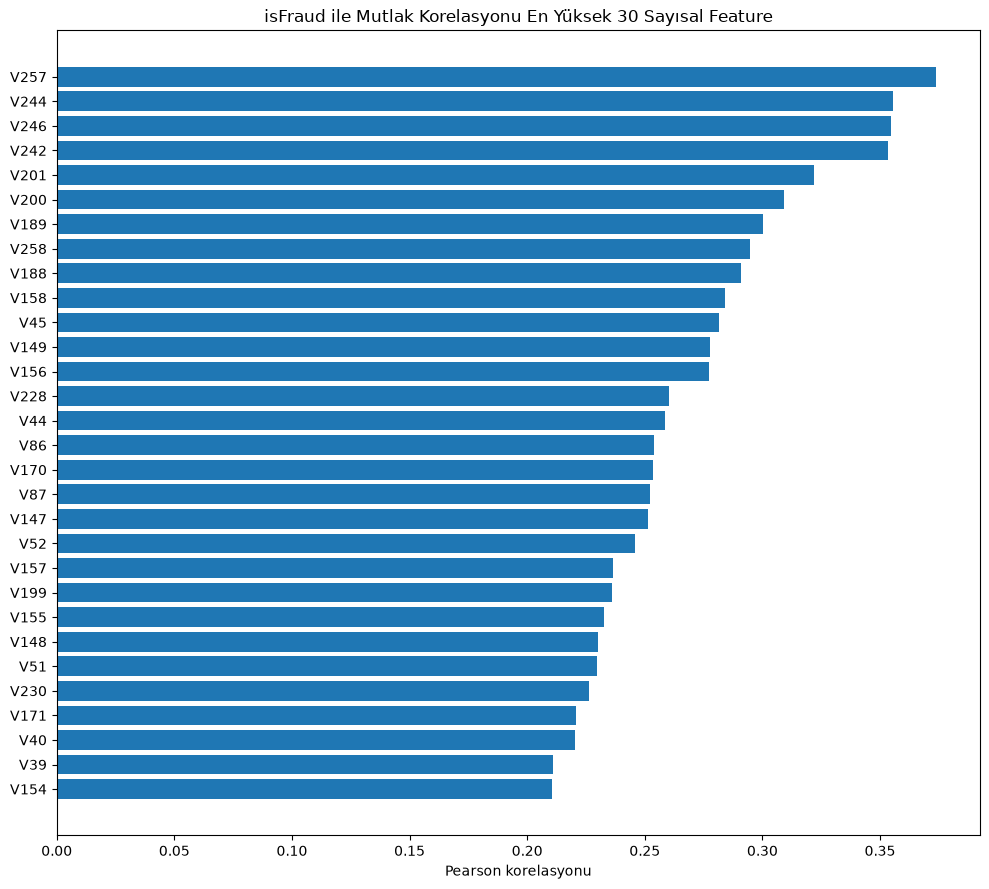

In [14]:

# 14) SAYISAL KORELASYONLAR
numeric_cols=(train_df.select_dtypes(include=[np.number]).columns
              .difference(['isFraud','TransactionID','_has_identity','_transaction_day']).tolist())
corr_df=train_df[numeric_cols+['isFraud']]
if len(corr_df)>PLOT_SAMPLE_SIZE:
    corr_df=corr_df.sample(PLOT_SAMPLE_SIZE, random_state=RANDOM_STATE)
with step('Sayısal target korelasyonları'):
    corr=(corr_df.corr(numeric_only=True)['isFraud']
          .drop('isFraud').dropna()
          .sort_values(key=lambda s:s.abs(), ascending=False)
          .reset_index())
corr.columns=['feature','correlation_with_isFraud']
corr.to_csv(OUTPUT_DIR/'ieee_numeric_target_correlations.csv', index=False)
display(corr.head(TOP_CORRELATION_COLUMNS))
p=corr.head(TOP_CORRELATION_COLUMNS).sort_values('correlation_with_isFraud')
plt.figure(figsize=(10,9))
plt.barh(p['feature'], p['correlation_with_isFraud'])
plt.title(f'isFraud ile Mutlak Korelasyonu En Yüksek {TOP_CORRELATION_COLUMNS} Sayısal Feature')
plt.xlabel('Pearson korelasyonu')
savefig('07_top_numeric_target_correlations.png')
plt.show(); plt.close()


# 8. Cardinality ve Sabit Kolonlar

In [15]:

# 15) CARDINALITY RAPORU
cardinality=pd.DataFrame({
    'column':train_df.columns,
    'dtype':train_df.dtypes.astype(str).values,
    'unique_count':[train_df[c].nunique(dropna=False) for c in tqdm(train_df.columns, desc='Cardinality')],
    'missing_ratio':train_df.isna().mean().values
})
cardinality['unique_ratio']=cardinality['unique_count']/len(train_df)
cardinality=cardinality.sort_values('unique_count',ascending=False).reset_index(drop=True)
cardinality.to_csv(OUTPUT_DIR/'ieee_feature_cardinality.csv', index=False)
display(cardinality.head(30))
constant_cols=cardinality.loc[cardinality['unique_count']<=1,'column'].tolist()
print('Sabit kolon sayısı:', len(constant_cols))
print(constant_cols)


Cardinality: 100%|██████████| 436/436 [00:01<00:00, 361.00it/s]


,column,dtype,unique_count,missing_ratio,unique_ratio
0,TransactionID,int32,590540,0.000000,1.000000
1,TransactionDT,int32,573349,0.000000,0.970889
2,id_02,float32,115656,0.761452,0.195848
3,V307,float32,37368,0.000020,0.063278
4,V127,float32,24415,0.000532,0.041344
5,V308,float32,23065,0.000020,0.039057
6,TransactionAmt,float32,20902,0.000000,0.035395
7,V310,float32,19137,0.000020,0.032406
8,V306,float32,16211,0.000020,0.027451
9,V317,float32,15185,0.000020,0.025714


Sabit kolon sayısı: 0
[]


# 9. EDA Özeti ve Çıktılar

In [16]:
# 16) ÖZET DOSYALARINI KAYDET
summary={
    'dataset':'IEEE-CIS Fraud Detection',
    'train_transaction_shape':[int(train_transaction.shape[0]),int(train_transaction.shape[1])],
    'merged_train_shape':[int(train_df.shape[0]),int(train_df.shape[1])],
    'normal_transactions':normal_count,
    'fraud_transactions':fraud_count,
    'fraud_ratio':fraud_ratio,
    'normal_to_fraud_ratio':normal_count/max(fraud_count,1),
    'duplicate_rows':int(train_df.duplicated().sum()),
    'identity_coverage_ratio':float(train_df['_has_identity'].mean()),
    'columns_without_missing':int((missing_report['missing_ratio']==0).sum()),
    'columns_over_50_percent_missing':int((missing_report['missing_ratio']>.50).sum()),
    'columns_over_90_percent_missing':int((missing_report['missing_ratio']>.90).sum()),
    'constant_columns':constant_cols,
    'top_missing_columns':missing_report.head(20)[['column','missing_ratio','unique_count']].to_dict('records'),
    'top_numeric_target_correlations':corr.head(20).to_dict('records')
}
with open(OUTPUT_DIR/'ieee_eda_summary.json','w',encoding='utf-8') as f:
    json.dump(summary,f,ensure_ascii=False,indent=2)

md_lines = [
    '# IEEE-CIS Fraud Detection — EDA Özeti',
    '',
    f'- Train transaction: {train_transaction.shape[0]:,} satır, {train_transaction.shape[1]} kolon',
    f'- Birleştirilmiş train: {train_df.shape[0]:,} satır, {train_df.shape[1]} kolon',
    f'- Normal işlem: {normal_count:,}',
    f'- Fraud işlem: {fraud_count:,}',
    f'- Fraud oranı: {fraud_ratio:.4%}',
    f'- Normal/Fraud oranı: {normal_count/max(fraud_count,1):.2f}',
    f'- Identity kapsama oranı: {train_df["_has_identity"].mean():.2%}',
    f'- Duplicate satır: {train_df.duplicated().sum():,}',
    f'- %50 üzeri eksik kolon: {(missing_report["missing_ratio"]>.50).sum()}',
    f'- %90 üzeri eksik kolon: {(missing_report["missing_ratio"]>.90).sum()}',
    '',
    '## İlk değerlendirme',
    '',
    '- Veri seti ciddi class imbalance içermektedir.',
    '- Accuracy tek başına yeterli değildir.',
    '- Identity bilgisi bütün işlemlerde bulunmamaktadır.',
    '- Eksik oranı yüksek kolonlar model denemesi yapılmadan doğrudan silinmemelidir.',
    '- Modelleme aşamasında PR-AUC, recall, precision, F1 ve confusion matrix birlikte değerlendirilmelidir.',
]
md = '\n'.join(md_lines)
(OUTPUT_DIR/'ieee_eda_summary.md').write_text(md,encoding='utf-8')
print('Özetler kaydedildi.')


Özetler kaydedildi.


In [17]:
# 17) OLUŞTURULAN DOSYALARI LİSTELE
files=sorted([p for p in OUTPUT_DIR.iterdir() if p.is_file()], key=lambda p:p.name)
print(f'Toplam {len(files)} çıktı oluşturuldu:')
for p in files:
    print(' -', p.name)
print()
print('IEEE-CIS EDA tamamlandı.')


Toplam 48 çıktı oluşturuldu:
 - 01_class_distribution.png
 - 02_identity_presence_fraud_rate.png
 - 03_top_missing_columns.png
 - 04_transaction_amount_log_distribution.png
 - 05_daily_transaction_count.png
 - 06_daily_fraud_rate.png
 - 07_top_numeric_target_correlations.png
 - categorical_DeviceType_fraud_rate.png
 - categorical_DeviceType_summary.csv
 - categorical_M1_fraud_rate.png
 - categorical_M1_summary.csv
 - categorical_M2_fraud_rate.png
 - categorical_M2_summary.csv
 - categorical_M3_fraud_rate.png
 - categorical_M3_summary.csv
 - categorical_M4_fraud_rate.png
 - categorical_M4_summary.csv
 - categorical_M5_fraud_rate.png
 - categorical_M5_summary.csv
 - categorical_M6_fraud_rate.png
 - categorical_M6_summary.csv
 - categorical_M7_fraud_rate.png
 - categorical_M7_summary.csv
 - categorical_M8_fraud_rate.png
 - categorical_M8_summary.csv
 - categorical_M9_fraud_rate.png
 - categorical_M9_summary.csv
 - categorical_P_emaildomain_fraud_rate.png
 - categorical_P_emaildomain_summa


# EDA Sonrası Kontrol Listesi

- [ ] Fraud oranı ve dengesizlik oranı bulundu.
- [ ] Identity kapsama oranı ölçüldü.
- [ ] Eksik oranı yüksek kolonlar belirlendi.
- [ ] TransactionAmt ve TransactionDT incelendi.
- [ ] Temel kategorik kolonların fraud oranları çıkarıldı.
- [ ] Sayısal feature-target korelasyonları raporlandı.
- [ ] Sabit ve yüksek cardinality kolonlar belirlendi.
- [ ] Çıktılar `assets/sprint-2/ieee-eda/` altına kaydedildi.

Bu notebook tamamlandıktan sonra preprocessing ve modelleme aşamasına geçilmelidir.
